

**To Know**

This lab implementation demonstrates how to build a time series analysis of real-world match data using data science and analytical exploration.
We visualise each series and record to gain deeper insights and observe trends in the data.

This lab is prepared by **Eric Kella Mwinwule** as part of Data Analysis and Visualisation Lab implementation.



## importing packages ##

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Now we are going to use match results datasets for sports  ###

In [3]:
sports = pd.read_csv('Match_Results.csv')

In [4]:
sports 

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
47394,2024-07-10,Netherlands,England,1,2,UEFA Euro,Dortmund,Germany,True
47395,2024-07-10,Uruguay,Colombia,0,1,Copa América,Charlotte,United States,True
47396,2024-07-13,Canada,Uruguay,2,2,Copa América,Charlotte,United States,True
47397,2024-07-14,Spain,England,2,1,UEFA Euro,Berlin,Germany,True


### Data Cleaning (Seltecting the relevant dataframe) ###

In [6]:
sports[['date', 'country', 'city', 'tournament','home_score', 'away_score']]

,date,country,city,tournament,home_score,away_score
0,1872-11-30,Scotland,Glasgow,Friendly,0,0
1,1873-03-08,England,London,Friendly,4,2
2,1874-03-07,Scotland,Glasgow,Friendly,2,1
3,1875-03-06,England,London,Friendly,2,2
4,1876-03-04,Scotland,Glasgow,Friendly,3,0
...,...,...,...,...,...,...
47394,2024-07-10,Germany,Dortmund,UEFA Euro,1,2
47395,2024-07-10,United States,Charlotte,Copa América,0,1
47396,2024-07-13,United States,Charlotte,Copa América,2,2
47397,2024-07-14,Germany,Berlin,UEFA Euro,2,1


In [16]:
sports['date'] = pd.to_datetime(sports['date'])

sports.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


### Removing neutral column from the dataset ###

In [15]:
sports.drop(columns=['neutral'])

,date,home_team,away_team,home_score,away_score,tournament,city,country
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland
1,1873-03-08,England,Scotland,4,2,Friendly,London,England
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland
3,1875-03-06,England,Scotland,2,2,Friendly,London,England
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland
...,...,...,...,...,...,...,...,...
47394,2024-07-10,Netherlands,England,1,2,UEFA Euro,Dortmund,Germany
47395,2024-07-10,Uruguay,Colombia,0,1,Copa América,Charlotte,United States
47396,2024-07-13,Canada,Uruguay,2,2,Copa América,Charlotte,United States
47397,2024-07-14,Spain,England,2,1,UEFA Euro,Berlin,Germany


### Visualization ### 
### 1. Line Chart ###

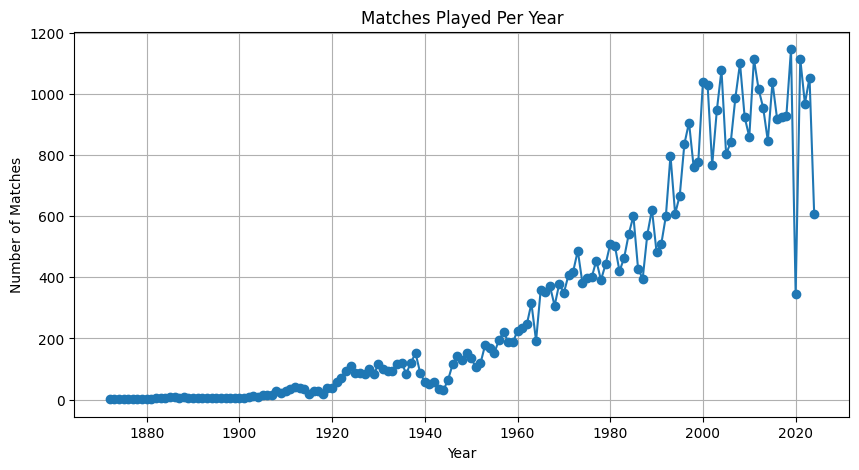

In [45]:
matches_per_year = sports.groupby(sports['date'].dt.year).size()

plt.figure(figsize=(10,5))
plt.plot(matches_per_year.index, matches_per_year.values, marker='o')
plt.title("Matches Played Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.grid(True)
plt.show()

### 2. Bar Chart ###

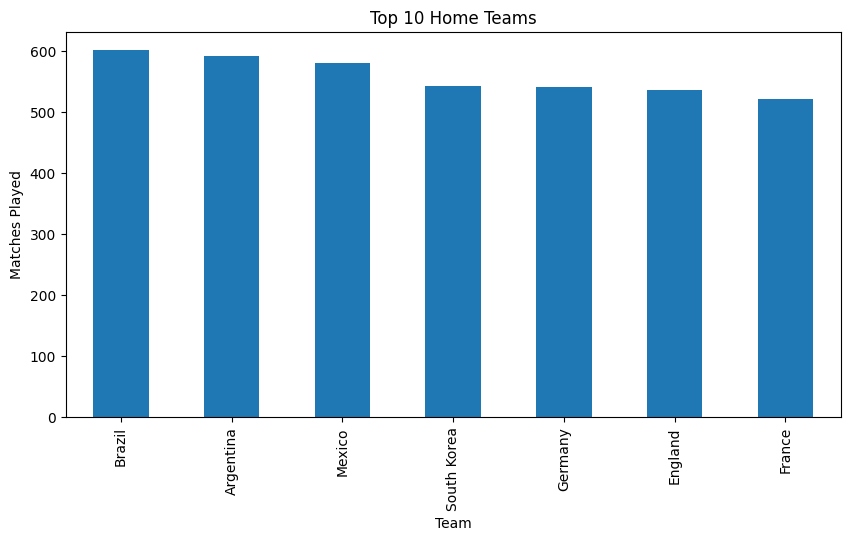

In [18]:
top_teams = sports['home_team'].value_counts().head(7)

plt.figure(figsize=(10,5))
top_teams.plot(kind='bar')
plt.title("Top 10 Home Teams")
plt.xlabel("Team")
plt.ylabel("Matches Played")
plt.show()

### 3. Pie Chart Visualisation ###

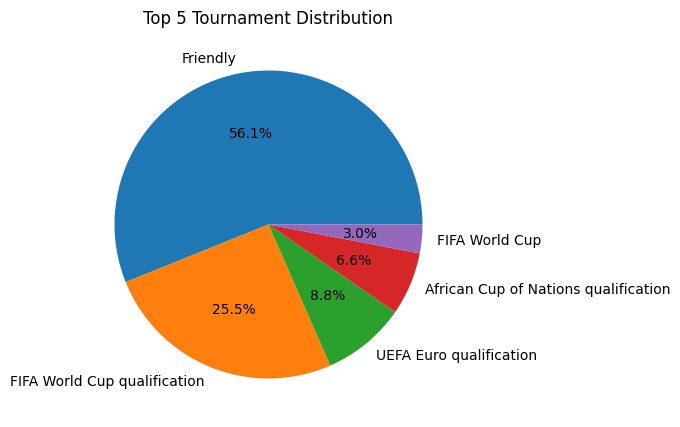

In [21]:
sports['tournament'].value_counts().head(5).plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5,5)
)

plt.title("Top 5 Tournament Distribution")
plt.ylabel("")
plt.show()

### 4. Histogram ###

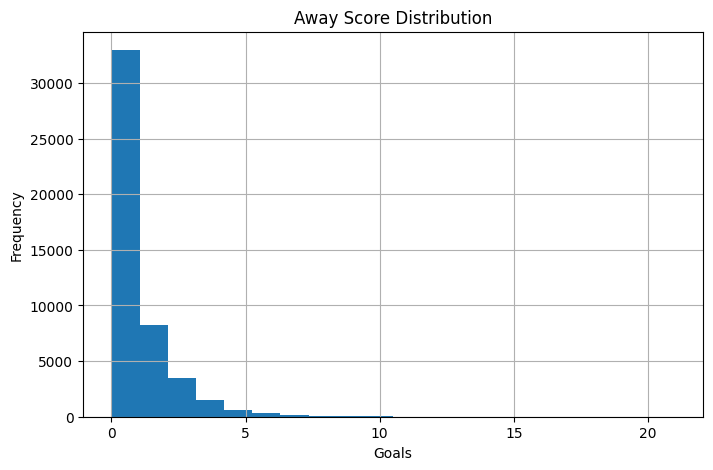

In [23]:
plt.figure(figsize=(8,5))
sports['away_score'].hist(bins=20)
plt.title("Away Score Distribution")
plt.xlabel("Goals")
plt.ylabel("Frequency")
plt.show()

### 5. Scatter Plot ###
#### Checking home score vrs away score ####

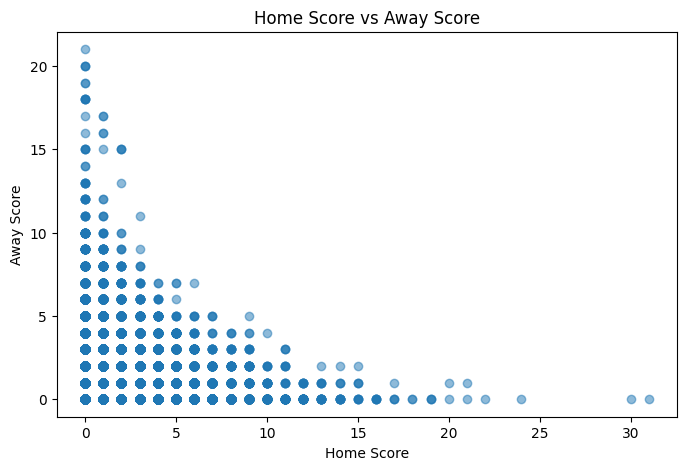

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(
    sports['home_score'],
    sports['away_score'],
    
    alpha=0.5
)

plt.title("Home Score vs Away Score")
plt.xlabel("Home Score")
plt.ylabel("Away Score")
plt.show()

###  6. Box Plot ###
#### Plotting countries and cities where matches were played ####

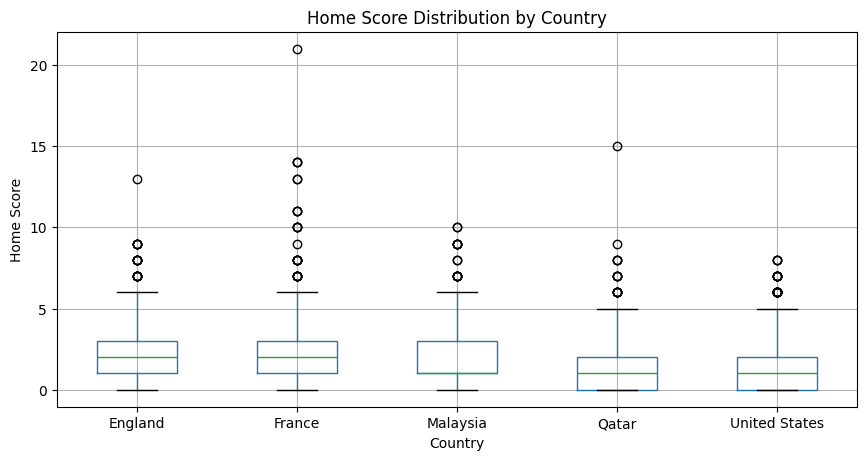

In [36]:
top_countries = sports['country'].value_counts().head(5).index

sports[sports['country'].isin(top_countries)].boxplot(
    column='home_score',
    by='country',
    figsize=(10,5)
)

plt.title("Home Score Distribution by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Home Score")
plt.show()

### 7. Area Chart ##

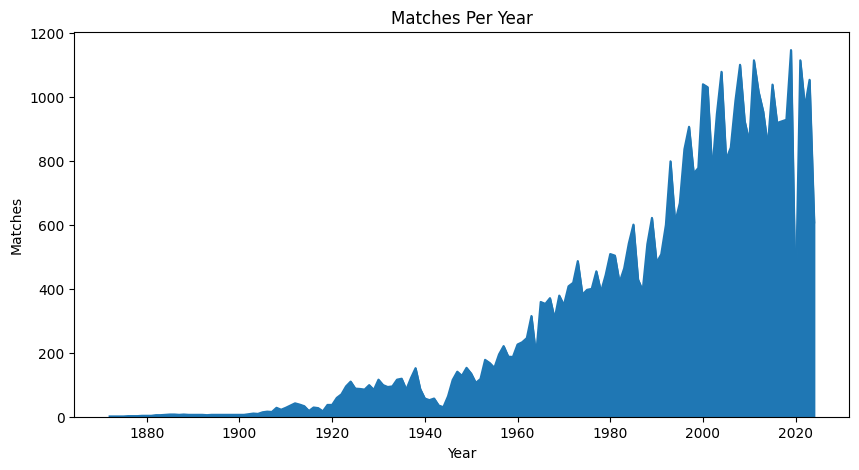

In [37]:
matches_per_year.plot.area(figsize=(10,5))

plt.title("Matches Per Year")
plt.xlabel("Year")
plt.ylabel("Matches")
plt.show()

### 8.  Density Plot ###
A density plot (or kernel density estimate plot) is a smoothed, continuous version of a histogram that visualizes the distribution of data points across a range. Instead of grouping data into jagged bins, it uses a non-parametric mathematical approach to estimate the continuous Probability Density Function (PDF) of a random variable. 

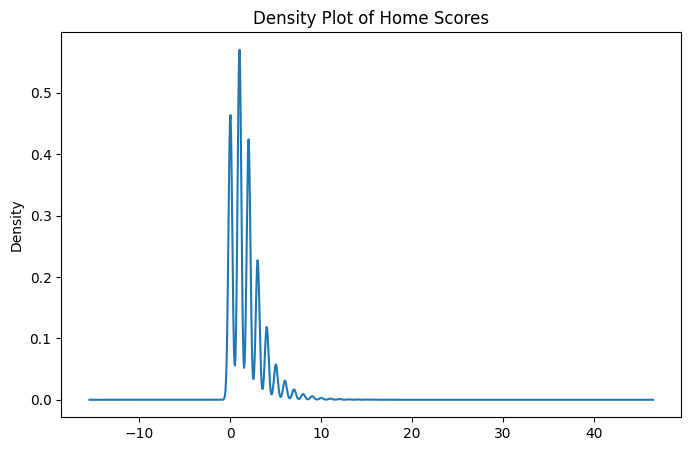

In [39]:
sports['home_score'].plot(
    kind='density',
    figsize=(8,5)
)

plt.title("Density Plot of Home Scores")
plt.show()

### 9. Correlation Heatmap Plot ###

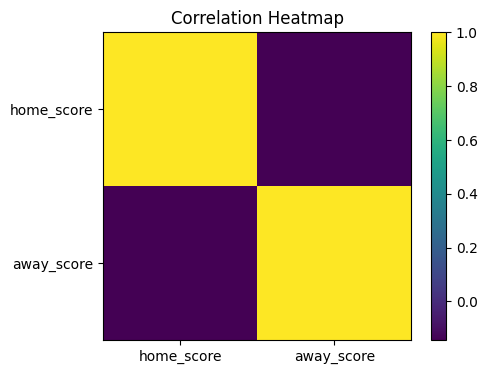

In [41]:
corr = sports[['home_score', 'away_score']].corr()

plt.figure(figsize=(5,4))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

### 10 How to Save a Chart ##

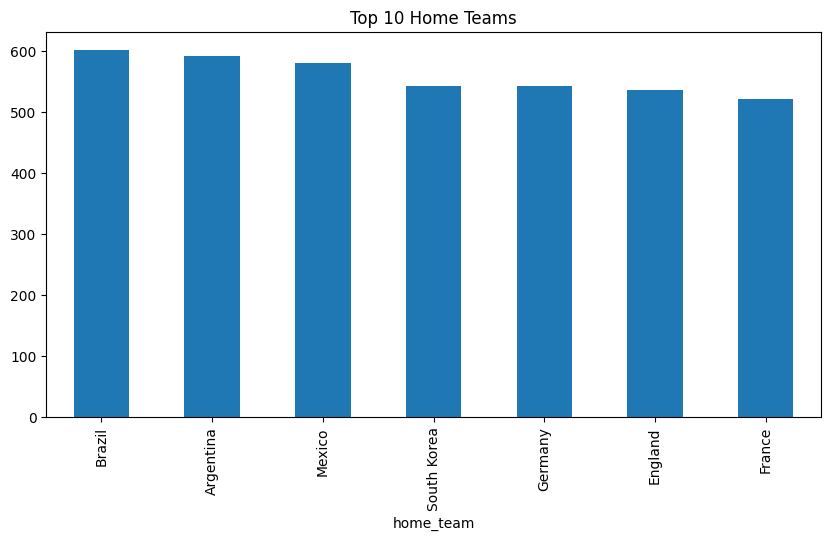

In [43]:
plt.figure(figsize=(10,5))
top_teams.plot(kind='bar')
plt.title("Top 10 Home Teams")

plt.savefig("top_home_teams.png")

Any Question ?